In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

Извлечение данных:

In [2]:
# Узнаем названия всех колонок
all_cols = pd.read_csv('./exam.csv', sep=';', nrows=0).columns
# Читаем нужный диапазон
df = pd.read_csv('./exam.csv',
                 sep=';',
                 skiprows=100,
                 nrows=51,
                 names=all_cols)
# Оставляем нужные столбцы
final_data = df[['lesson_price', 'mean_exam_points']]
# Вывод результата
print(f"Данные для варианта 25 (записи 100-150):")
print(final_data.head())

Данные для варианта 25 (записи 100-150):
   lesson_price  mean_exam_points
0        1950.0              40.0
1        1150.0              48.0
2        1500.0              74.0
3        1450.0              57.0
4        1400.0              59.0


In [3]:
x = final_data['lesson_price']
x

0     1950.0
1     1150.0
2     1500.0
3     1450.0
4     1400.0
5     1350.0
6     1500.0
7     1200.0
8      950.0
9     1300.0
10    1550.0
11    1700.0
12    1500.0
13    2800.0
14    1250.0
15    2550.0
16    2650.0
17    1150.0
18    1600.0
19    1700.0
20    1900.0
21    1600.0
22    1800.0
23    1300.0
24    2200.0
25    1750.0
26    1900.0
27    1400.0
28    1350.0
29    1300.0
30    1550.0
31    1550.0
32    1500.0
33    1200.0
34    1350.0
35    2150.0
36    1400.0
37    1650.0
38    1500.0
39    1550.0
40    1350.0
41    1600.0
42    1450.0
43    2200.0
44    2300.0
45    1450.0
46    1250.0
47     850.0
48    1500.0
49    2200.0
50    2250.0
Name: lesson_price, dtype: float64

In [4]:
y = final_data['mean_exam_points']
n = len(y)
y

0     40.0
1     48.0
2     74.0
3     57.0
4     59.0
5     50.0
6     45.0
7     47.0
8     67.0
9     60.0
10    39.0
11    64.0
12    64.0
13    84.0
14    62.0
15    64.0
16    81.0
17    58.0
18    43.0
19    60.0
20    50.0
21    69.0
22    62.0
23    61.0
24    79.0
25    56.0
26    64.0
27    62.0
28    58.0
29    62.0
30    67.0
31    42.0
32    55.0
33    50.0
34    75.0
35    72.0
36    62.0
37    81.0
38    52.0
39    47.0
40    61.0
41    66.0
42    57.0
43    94.0
44    80.0
45    66.0
46    40.0
47    52.0
48    51.0
49    63.0
50    87.0
Name: mean_exam_points, dtype: float64

Построение графика:

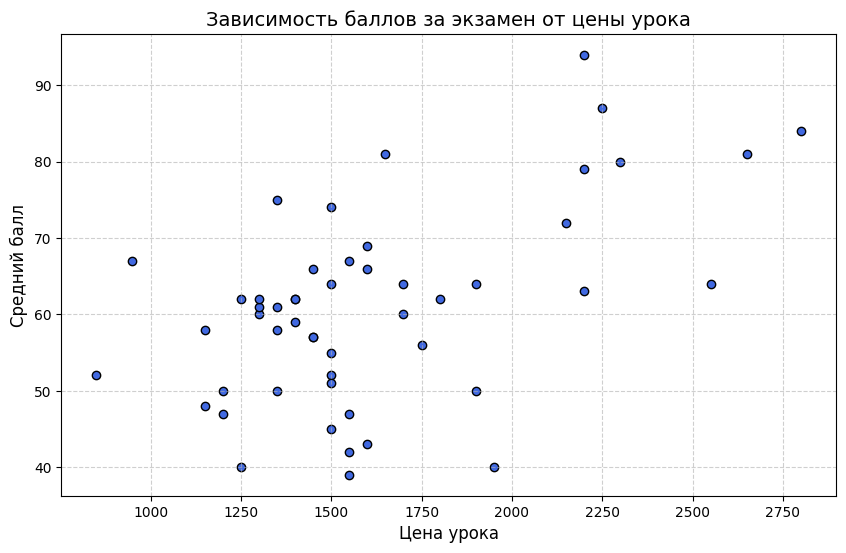

In [5]:
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='royalblue', edgecolors='black')

# Оформление
plt.title('Зависимость баллов за экзамен от цены урока', fontsize=14)
plt.xlabel('Цена урока', fontsize=12)
plt.ylabel('Средний балл', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Показываем результат
plt.show()

Выберем точки и найдем вручную коэффициенты линейной регрессии:

In [6]:
sample_3 = final_data.sort_values('lesson_price').iloc[[0, 25, -1]]
print("Выбранные точки для ручного расчета:")
print(sample_3)

Выбранные точки для ручного расчета:
    lesson_price  mean_exam_points
47         850.0              52.0
2         1500.0              74.0
13        2800.0              84.0


Построим график:

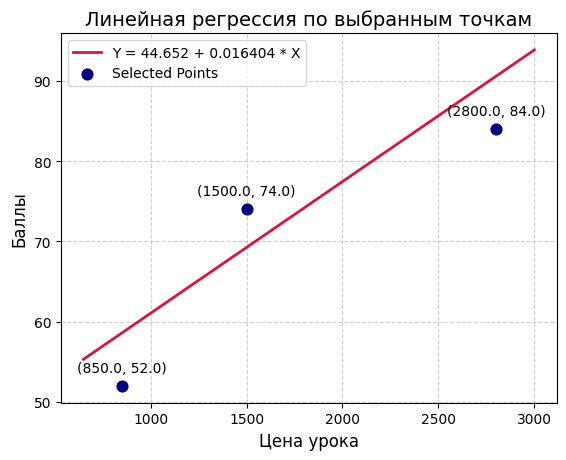

In [7]:
# Исходные точки
x_points = sample_3['lesson_price'].values
y_points = sample_3['mean_exam_points'].values

# Вычисленные вручную коэффициенты
w0 = 44.652
w1 = 0.016404

# Точки для построения
x_min, x_max = x_points.min() - 200, x_points.max() + 200
x_line = np.linspace(x_min, x_max, 100)
y_line = w0 + w1 * x_line

# График
plt.plot(x_line, y_line, color='crimson', label=f'Y = {w0} + {w1} * X', linewidth=2)
plt.scatter(x_points, y_points, color='navy', s=60, zorder=5, label='Selected Points')

# Оформление
plt.title('Линейная регрессия по выбранным точкам', fontsize=14)
plt.xlabel('Цена урока', fontsize=12)
plt.ylabel('Баллы', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Выводим координаты точек на график
for i in range(len(x_points)):
    plt.annotate(f'({x_points[i]}, {y_points[i]})',
                 (x_points[i], y_points[i]),
                 textcoords="offset points",
                 xytext=(0,10),
                 ha='center')

# Показываем результат
plt.show()

Найдем аналитическое решение с помощью библиотеки NumPy:

In [8]:
# Формируем матрицы X и Y
X = np.column_stack((np.ones_like(x), x))
Y = y

# Реализуем формулу w = (X^T * X)^-1 * X^T * Y
XTX = X.T @ X
XTX_inv = np.linalg.inv(XTX)
XTY = X.T @ Y
w = XTX_inv @ XTY

# Итоговые веса
w0_all = w[0]
w1_all = w[1]

# Итоговое уравнение
print(f"\nПараметры регрессии для всей выборки:")
print(f"w0 = {w0_all:.4f}")
print(f"w1 = {w1_all:.4f}")
print(f"Итоговое уравнение: Y = {w0_all:.4f} + {w1_all:.4f} * X")


Параметры регрессии для всей выборки:
w0 = 34.8261
w1 = 0.0162
Итоговое уравнение: Y = 34.8261 + 0.0162 * X


Построим график полученного решения:

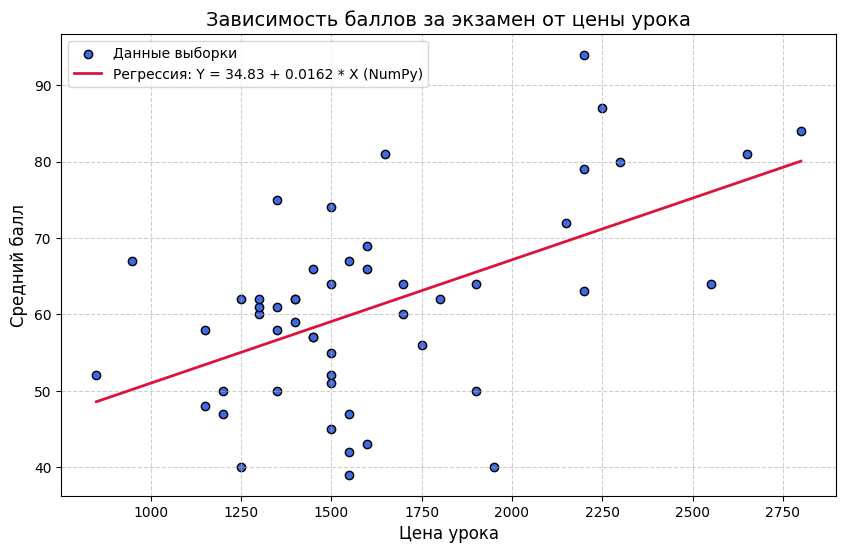

In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='royalblue', edgecolors='black', label='Данные выборки')

# Линия регрессии
x_line = np.array([x.min(), x.max()])
y_line = w0_all + w1_all * x_line
plt.plot(x_line, y_line, color='crimson', linewidth=2,
         label=f'Регрессия: Y = {w0_all:.2f} + {w1_all:.4f} * X (NumPy)')

# Оформление
plt.title('Зависимость баллов за экзамен от цены урока', fontsize=14)
plt.xlabel('Цена урока', fontsize=12)
plt.ylabel('Средний балл', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Показываем результат
plt.show()

Поиск оптимальных значений параметров линейной регрессии различными методами:

In [10]:
# Параметры из условия
eps = 0.0001
eta = 0.001
max_iter = 10000

# Функция для вычисления градиента
def calc_gradients(x_batch, y_batch, w0, w1):
    n_batch = len(y_batch)
    y_pred = w0 + w1 * x_batch
    error = y_pred - y_batch
    grad0 = (2 / n_batch) * np.sum(error)
    grad1 = (2 / n_batch) * np.sum(error * x_batch)
    return grad0, grad1

Пакетный градиентный спуск:

In [11]:
# Начальное приближение
w0_batch, w1_batch = 0.0, 0.0
iterations = 0
history_batch = []
history_mse_batch = []

# Нормализация
x_norm = (x - np.mean(x)) / np.std(x)

while iterations < max_iter:
    g0, g1 = calc_gradients(x_norm, y, w0_batch, w1_batch)

    w0_new = w0_batch - eta * g0
    w1_new = w1_batch - eta * g1

    # MSE
    y_pred = w0_new + w1_new * x_norm
    current_mse = np.mean((y - y_pred)**2)
    history_mse_batch.append(current_mse)

    # Изменение весов
    delta = np.sqrt((w0_new - w0_batch)**2 + (w1_new - w1_batch)**2)
    history_batch.append(delta)

    # Условие выхода
    if delta < eps:
        break

    w0_batch, w1_batch = w0_new, w1_new
    iterations += 1

# Возвращаем коэффициенты к исходному масштабу
mu = np.mean(x)
sigma = np.std(x)

w1_orig = w1_batch / sigma
w0_orig = w0_batch - (w1_batch * mu / sigma)

print(f"Пакетный градиентный спуск:")
print(f"w0 = {w0_orig:.4f}")
print(f"w1 = {w1_orig:.4f}")

Пакетный градиентный спуск:
w0 = 34.7978
w1 = 0.0161


Построим график ошибок:

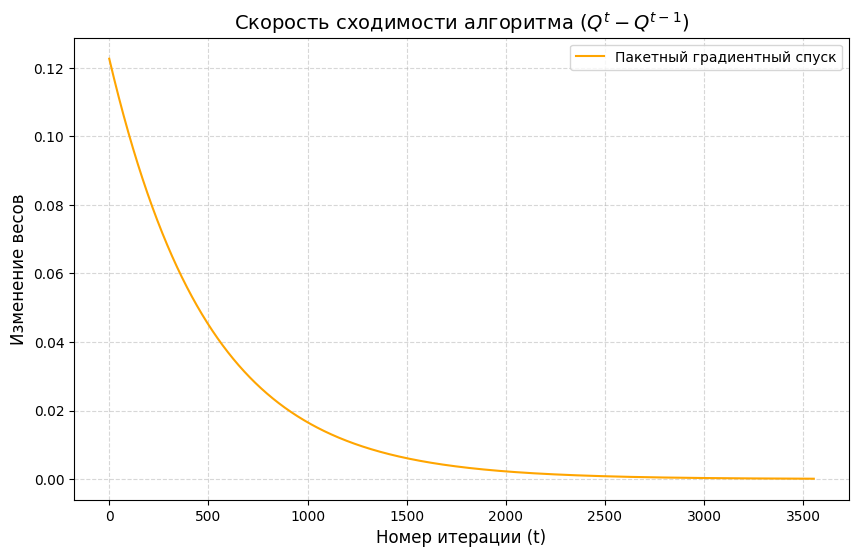

In [12]:
plt.figure(figsize=(10, 6))

# Строим график
plt.plot(history_batch, label='Пакетный градиентный спуск', color='orange')

# Оформление
plt.title('Скорость сходимости алгоритма ($Q^t - Q^{t-1}$)', fontsize=14)
plt.xlabel('Номер итерации (t)', fontsize=12)
plt.ylabel('Изменение весов', fontsize=12)

plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend()

plt.show()

График MSE:

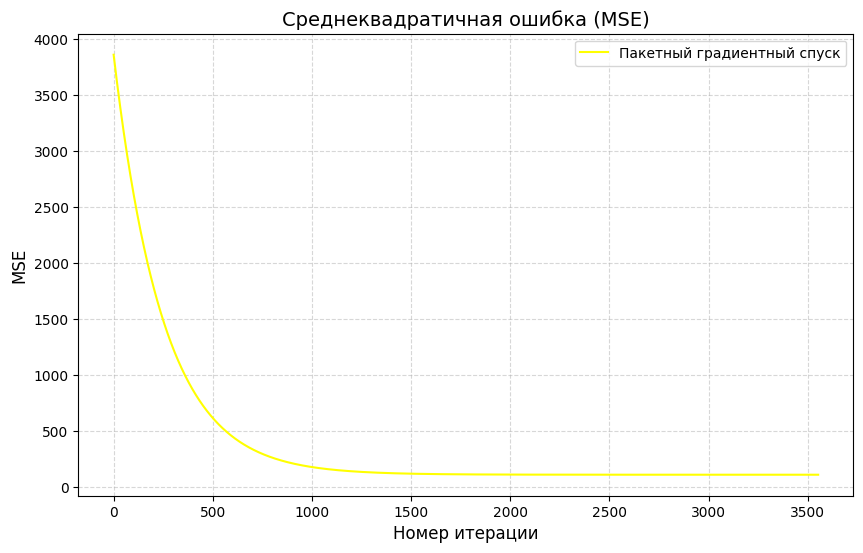

In [13]:
plt.figure(figsize=(10, 6))

# Строим график
plt.plot(history_mse_batch, label='Пакетный градиентный спуск', color='yellow')

# Оформление
plt.title('Среднеквадратичная ошибка (MSE)', fontsize=14)
plt.xlabel('Номер итерации', fontsize=12)
plt.ylabel('MSE', fontsize=12)

plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend()

plt.show()

Стохастический градиентный спуск:

In [14]:
# Нормализация
x_norm = (x - np.mean(x)) / np.std(x)
n = len(y)
history_sgd = []
history_mse_sgb = []

# Начальное приближение
w0_sgd, w1_sgd = 0.0, 0.0
iterations_sgd = 0

while iterations_sgd < max_iter:
    # Выбираем случайный индекс (одну точку)
    idx = np.random.randint(0, n)
    xi = np.array([x_norm[idx]])
    yi = np.array([y[idx]])

    # Считаем градиент только по этой одной точке
    g0, g1 = calc_gradients(xi, yi, w0_sgd, w1_sgd)

    w0_new = w0_sgd - eta * g0
    w1_new = w1_sgd - eta * g1

    # MSE
    y_pred = w0_new + w1_new * x_norm
    current_mse = np.mean((y - y_pred)**2)
    history_mse_sgb.append(current_mse)

    # Изменение весов
    delta = np.sqrt((w0_new - w0_sgd)**2 + (w1_new - w1_sgd)**2)
    history_sgd.append(delta)

    # Условие выхода
    if delta < eps:
        break

    w0_sgd, w1_sgd = w0_new, w1_new
    iterations_sgd += 1

# Возвращаем коэффициенты к исходному масштабу
mu = np.mean(x)
sigma = np.std(x)

w1_sgd_orig = w1_sgd / sigma
w0_sgd_orig = w0_sgd - (w1_sgd * mu / sigma)

print(f"Стохастический градиентный спуск:")
print(f"w0 = {w0_sgd_orig:.4f}")
print(f"w1 = {w1_sgd_orig:.4f}")
print(f"Итераций: {iterations_sgd}")

Стохастический градиентный спуск:
w0 = 32.0849
w1 = 0.0138
Итераций: 1132


Построим график ошибок:

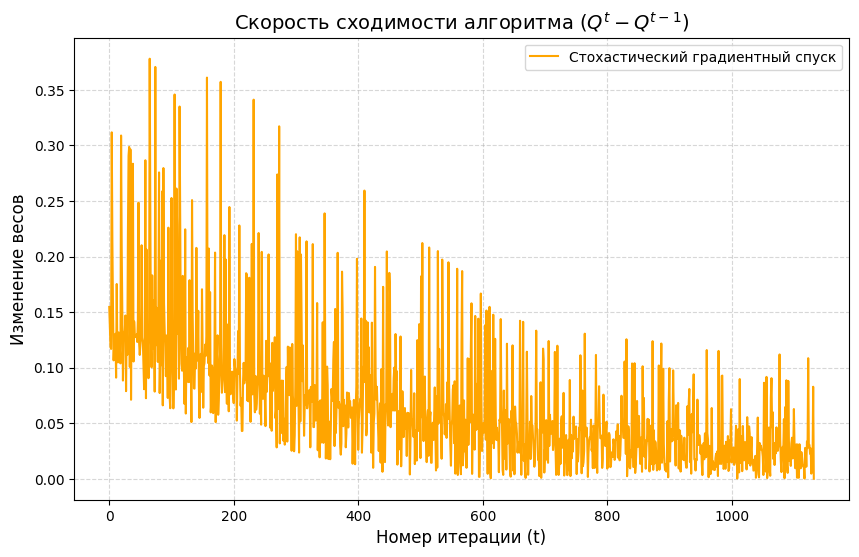

In [15]:
plt.figure(figsize=(10, 6))

# Строим график
plt.plot(history_sgd, label='Стохастический градиентный спуск', color='orange')

# Оформление
plt.title('Скорость сходимости алгоритма ($Q^t - Q^{t-1}$)', fontsize=14)
plt.xlabel('Номер итерации (t)', fontsize=12)
plt.ylabel('Изменение весов', fontsize=12)

plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend()

plt.show()

График MSE:

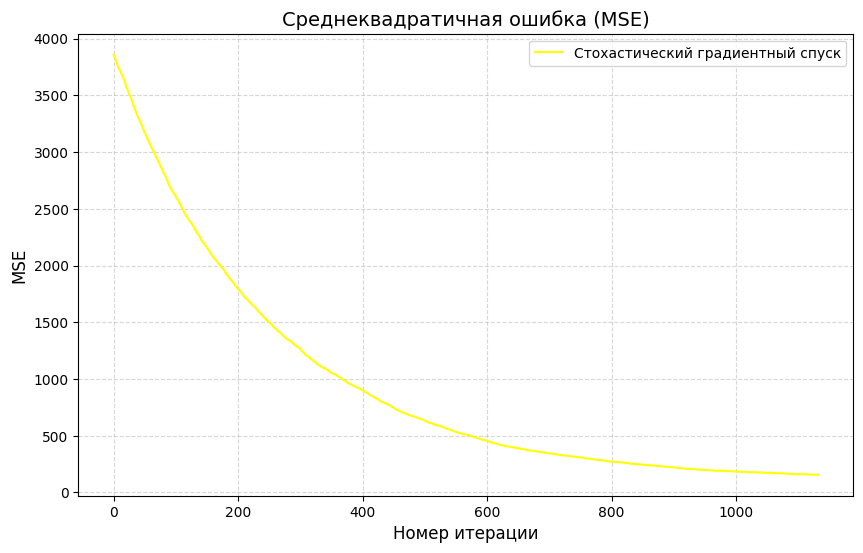

In [16]:
plt.figure(figsize=(10, 6))

# Строим график
plt.plot(history_mse_sgb, label='Стохастический градиентный спуск', color='yellow')

# Оформление
plt.title('Среднеквадратичная ошибка (MSE)', fontsize=14)
plt.xlabel('Номер итерации', fontsize=12)
plt.ylabel('MSE', fontsize=12)

plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend()

plt.show()

Мини-пакетный градиентный спуск:

In [17]:
# Параметры
batch_size = 10
w0_mini, w1_mini = 0.0, 0.0
iterations_mini = 0
n = len(y)
history_mini = []
history_mse_mini = []

while iterations_mini < max_iter:
    # Формируем мини-пакет: выбираем 10 случайных индексов
    indices = np.random.choice(n, batch_size, replace=False)
    x_batch = x_norm[indices]
    y_batch = y[indices]

    # Считаем градиент только по этой группе
    g0, g1 = calc_gradients(x_batch, y_batch, w0_mini, w1_mini)

    w0_new = w0_mini - eta * g0
    w1_new = w1_mini - eta * g1

    # MSE
    y_pred = w0_new + w1_new * x_norm
    current_mse = np.mean((y - y_pred)**2)
    history_mse_mini.append(current_mse)

    # Изменение весов
    delta = np.sqrt((w0_new - w0_mini)**2 + (w1_new - w1_mini)**2)
    history_mini.append(delta)

    # Условие выхода
    if delta < eps:
        break

    w0_mini, w1_mini = w0_new, w1_new
    iterations_mini += 1

# Возвращаем коэффициенты к исходному масштабу
w1_mini_orig = w1_mini / sigma
w0_mini_orig = w0_mini - (w1_mini * mu / sigma)

print(f"Мини-пакетный градиентный спуск:")
print(f"w0 = {w0_mini_orig:.4f}")
print(f"w1 = {w1_mini_orig:.4f}")
print(f"Итераций: {iterations_mini}")

Мини-пакетный градиентный спуск:
w0 = 34.3963
w1 = 0.0153
Итераций: 1766


Построим график ошибок:

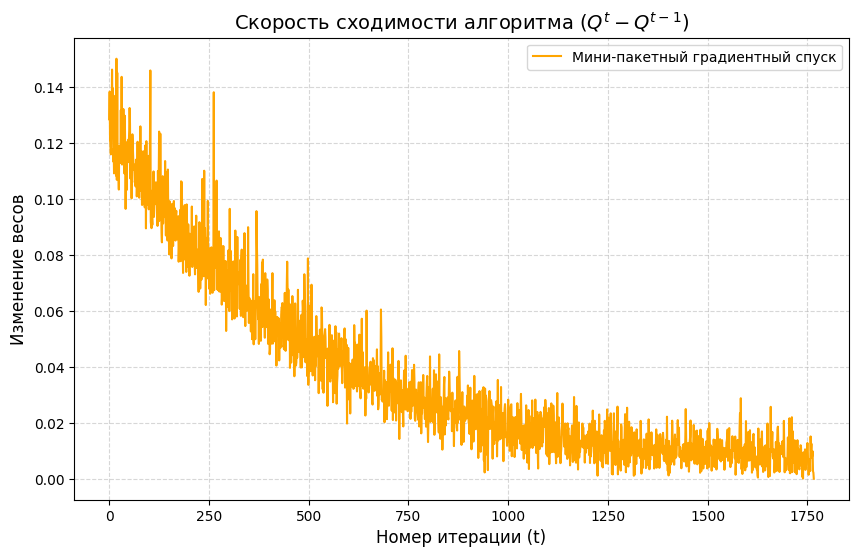

In [18]:
plt.figure(figsize=(10, 6))

# Строим график
plt.plot(history_mini, label='Мини-пакетный градиентный спуск', color='orange')

# Оформление
plt.title('Скорость сходимости алгоритма ($Q^t - Q^{t-1}$)', fontsize=14)
plt.xlabel('Номер итерации (t)', fontsize=12)
plt.ylabel('Изменение весов', fontsize=12)

plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend()

plt.show()

График MSE:

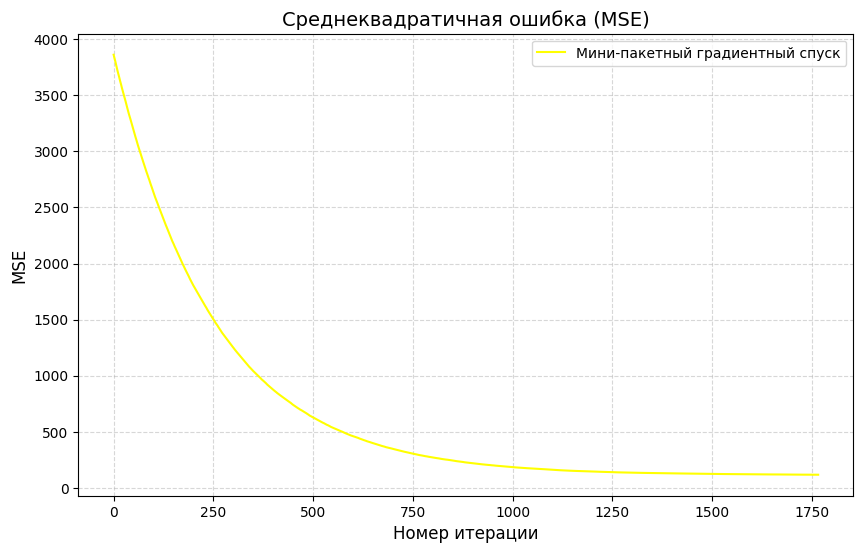

In [19]:
plt.figure(figsize=(10, 6))

# Строим график
plt.plot(history_mse_mini, label='Мини-пакетный градиентный спуск', color='yellow')

# Оформление
plt.title('Среднеквадратичная ошибка (MSE)', fontsize=14)
plt.xlabel('Номер итерации', fontsize=12)
plt.ylabel('MSE', fontsize=12)

plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend()

plt.show()

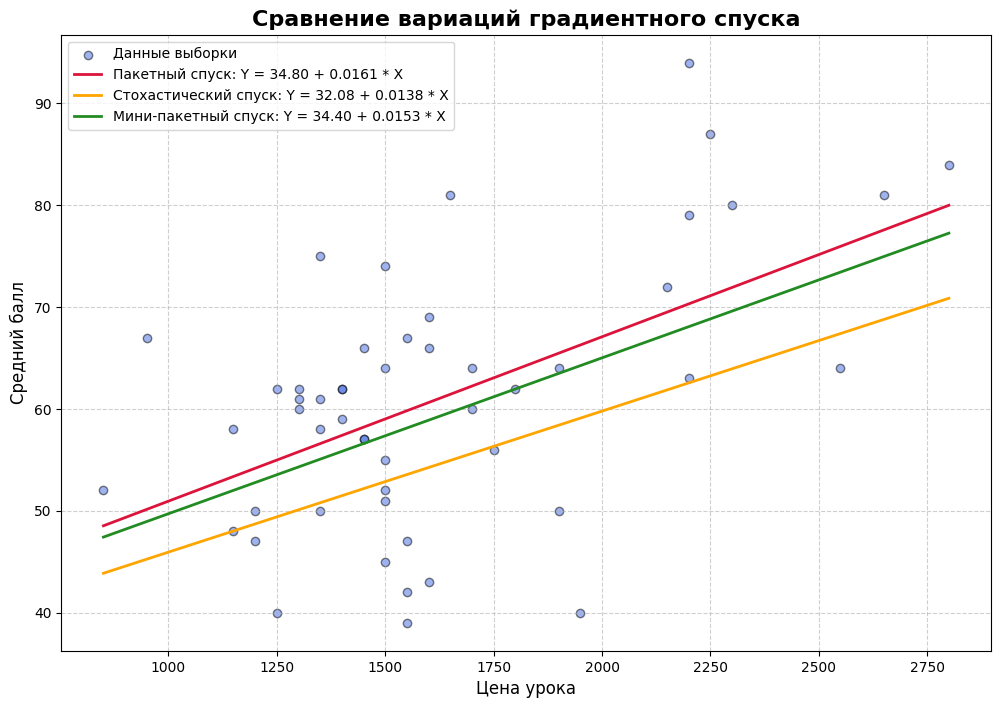

In [20]:
plt.figure(figsize=(12, 8))

# Основные точки данных
plt.scatter(x, y, color='royalblue', edgecolors='black', alpha=0.5, label='Данные выборки')

# Диапазон аргумента
x_plot = np.array([x.min(), x.max()])

# Линия пакетного спуска
y_batch_plot = w0_orig + w1_orig * x_plot
plt.plot(x_plot, y_batch_plot, color='crimson', linewidth=2,
         label=f'Пакетный спуск: Y = {w0_orig:.2f} + {w1_orig:.4f} * X')

# Линия стохастического спуска
y_sgd_plot = w0_sgd_orig + w1_sgd_orig * x_plot
plt.plot(x_plot, y_sgd_plot, color='orange', linewidth=2,
         label=f'Стохастический спуск: Y = {w0_sgd_orig:.2f} + {w1_sgd_orig:.4f} * X')

# Линия мини-пакетного спуска
y_mini_plot = w0_mini_orig + w1_mini_orig * x_plot
plt.plot(x_plot, y_mini_plot, color='forestgreen', linewidth=2,
         label=f'Мини-пакетный спуск: Y = {w0_mini_orig:.2f} + {w1_mini_orig:.4f} * X')

# Оформление
plt.title('Сравнение вариаций градиентного спуска', fontsize=16, fontweight='bold')
plt.xlabel('Цена урока', fontsize=12)
plt.ylabel('Средний балл', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Размещаем легенду
plt.legend(loc='upper left', fontsize=10)

plt.show()

Найдем уравнение линейной регрессии с помощью библиотеки scikit-learn:

In [21]:
# Подготовка данных
X = final_data['lesson_price'].values.reshape(-1, 1) # Создаем один столбец
y = final_data['mean_exam_points'].values

# Создание и обучение модели
model = LinearRegression()
model.fit(X, y)

# Извлечение коэффициентов
w0_sk = model.intercept_  # w0 (свободный член)
w1_sk = model.coef_[0]    # w1 (наклон)

print(f"Результат Scikit-learn:")
print(f"w0 = {w0_sk:.4f}")
print(f"w1 = {w1_sk:.4f}")
print(f"Уравнение: Y = {w0_sk:.4f} + {w1_sk:.4f} * X")

Результат Scikit-learn:
w0 = 34.8261
w1 = 0.0162
Уравнение: Y = 34.8261 + 0.0162 * X


Построим график:

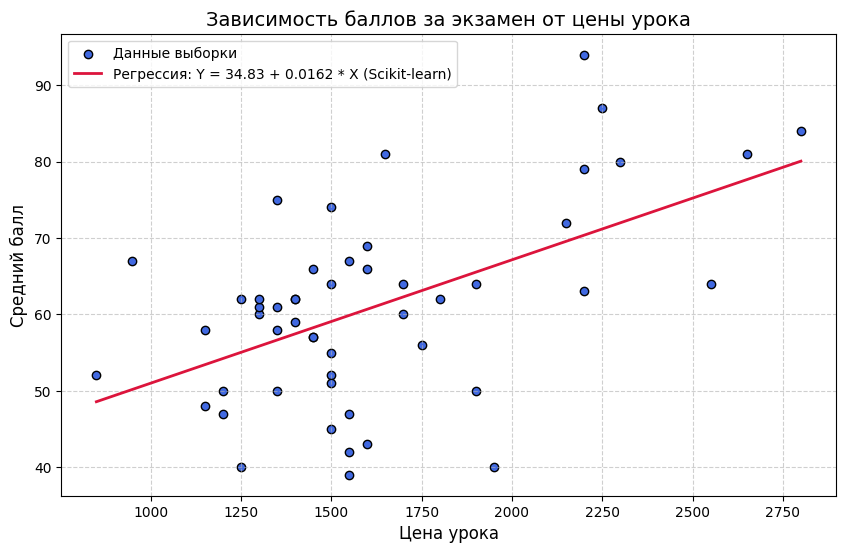

In [22]:
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='royalblue', edgecolors='black', label='Данные выборки')

# Линия регрессии
x_line = np.array([x.min(), x.max()])
y_line = w0_sk + w1_sk * x_line
plt.plot(x_line, y_line, color='crimson', linewidth=2,
         label=f'Регрессия: Y = {w0_sk:.2f} + {w1_sk:.4f} * X (Scikit-learn)')

# Оформление
plt.title('Зависимость баллов за экзамен от цены урока', fontsize=14)
plt.xlabel('Цена урока', fontsize=12)
plt.ylabel('Средний балл', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Показываем результат
plt.show()